# Description: Evaluate NORDIC ability at removing Thermal Noise (Evaluation Dataset)

Prior to using this notebook, you need to run the ```bash/S03_ThermalNoiseEstimation...``` script to estimate thermal noise in all scans and TEs from both datasets.

For each scan, this script will write two files:

* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt```: holds thermal noise estimates before applying NORDIC.
* ```{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt```: holds thermal noise estimates after applying NORDIC.

Expectations:

* Thermal noise should be TE independent, yet becuase the suboptimal way in which we are measuring thermal noise, a slight difference migth occur.
* Thermal noise should be significantly smaller after NORDIC for all echoes.

In [8]:
import pandas as pd
import os.path as osp
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from utils.basics import PRCS_DATA_DIR, PRJ_DIR
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt

from utils.basics import get_dataset_index

def set_fontsizes(fig, size=14):
    for ax in fig.axes:
        ax.title.set_fontsize(size)
        ax.xaxis.label.set_size(size)
        ax.yaxis.label.set_size(size)
        ax.tick_params(labelsize=size - 1)

        leg = ax.get_legend()
        if leg is not None:
            for t in leg.get_texts():
                t.set_fontsize(size - 1)
            if leg.get_title() is not None:
                leg.get_title().set_fontsize(size)



### Load list of scans from the Evaluation dataset entering the final set of analyses

In [2]:
DATASET = 'evaluation'
ds_index = get_dataset_index(DATASET)
ses_list = list(ds_index.get_level_values('Session').unique())
sbj_list = list(ds_index.get_level_values('Subject').unique())
dataset_info_df = pd.DataFrame(index=pd.MultiIndex.from_product([sbj_list,ses_list],names=['Subject','Session']))

++ Number of scans    = 439
++ Number of subjects = 221


### Load the Thermmal noise estiamtes for these scans

In [3]:
df_list = []
for sbj,ses in tqdm(dataset_info_df.index, desc='Scan'):
    for e in range(1,4):
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_off.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'m-NORDIC':'off','Echo':e,'Thermal Noise':np.mean(aux[10::])})
        aux_path = osp.join(PRCS_DATA_DIR,sbj,'D02_NORDIC',f'{sbj}_{ses}_task-rest_echo-{e}_bold.NORDIC_on.ThermalNoise.txt')
        aux      = np.loadtxt(aux_path)
        df_list.append( {'Subject':sbj,'Session':ses,'m-NORDIC':'on','Echo':e,'Thermal Noise':np.mean(aux[10::])})
df = pd.DataFrame(df_list)

Scan: 100%|██████████| 442/442 [00:01<00:00, 237.64it/s]


### Separate the data by session ID

In [4]:
df_ses1 = df.set_index('Session').loc['ses-1'].copy().reset_index(drop=True)
df_ses2  = df.set_index('Session').loc['ses-2'].copy().reset_index(drop=True)

### Print the overall improvement in Thermal Noise for the whole dataset

In [5]:
aux = (100 * (df.set_index(['Subject','Session','m-NORDIC','Echo']).loc[:,:,'off',:] - df.set_index(['Subject','Session','m-NORDIC','Echo']).loc[:,:,'on',:]) / df.set_index(['Subject','Session','m-NORDIC','Echo']).loc[:,:,'off',:]).describe()
print('Thermal Noise reduction after m-NORDIC (%%): %0.2f +/- %0.2f' % (aux.loc['mean'].values[0],aux.loc['std'].values[0]))

Thermal Noise reduction after m-NORDIC (%): 28.80 +/- 1.83


### Generate Suppl. Figure 2.b panel

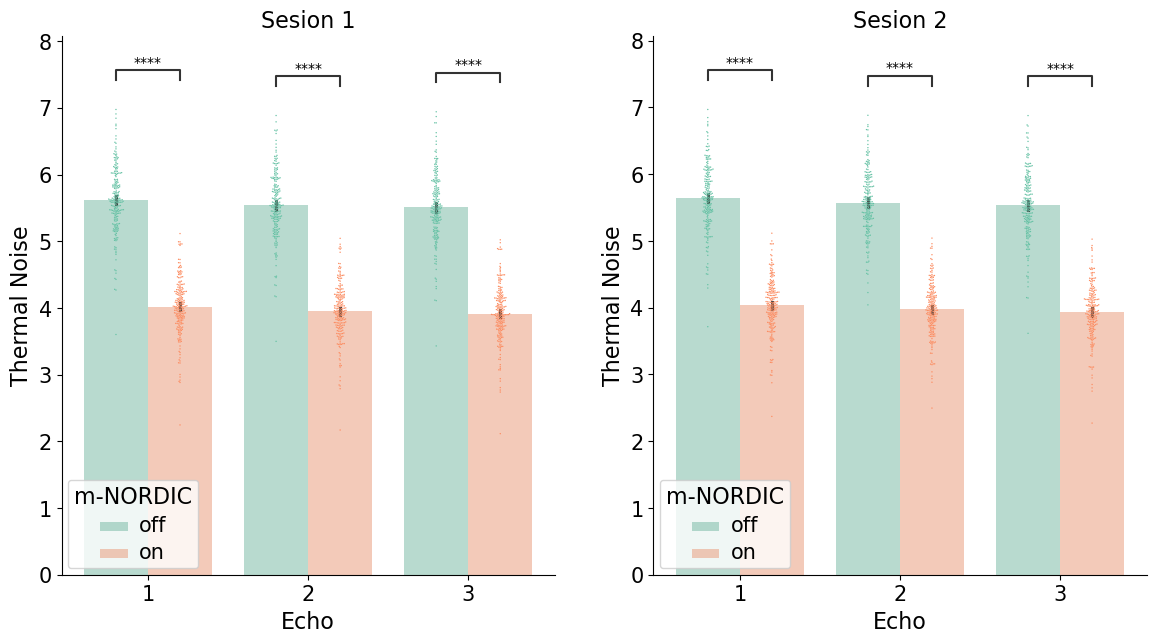

In [9]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
# Results for Constant Gated
sns.barplot(  data=df_ses1,hue='m-NORDIC',x='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[0], alpha=0.5).set_title('Sesion 1')
sns.swarmplot(data=df_ses1,hue='m-NORDIC',x='Echo',y='Thermal Noise', palette='Set2',ax=axs[0], dodge=True, legend=False, size=1)
pairs=[((1,'off'),(1,'on')),((2,'off'),(2,'on')),((3,'off'),(3,'on'))]
annotation = Annotator(axs[0], pairs, data=df_ses1, hue='m-NORDIC', y='Thermal Noise',x='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
# Results for Cardiac Gated
sns.barplot(  data=df_ses2,hue='m-NORDIC',x='Echo',y='Thermal Noise', palette='Set2', errorbar='ci', ax=axs[1], alpha=0.5).set_title('Sesion 2')
sns.swarmplot(data=df_ses2,hue='m-NORDIC',x='Echo',y='Thermal Noise', palette='Set2',ax=axs[1], dodge=True, legend=False, size=1)
pairs=[((1,'off'),(1,'on')),((2,'off'),(2,'on')),((3,'off'),(3,'on'))]
sns.despine()
annotation = Annotator(axs[1], pairs, data=df_ses2, hue='m-NORDIC', y='Thermal Noise',x='Echo')
annotation.configure(test='t-test_paired', loc='inside', verbose=0, comparisons_correction="Bonferroni");
annotation.apply_test(alternative='two-sided');
annotation.annotate();
set_fontsizes(fig, size=16);

In [10]:
fig.tight_layout()
fig.savefig('./figures/pBOLD_SuppFig02_b.png', bbox_inches="tight", pad_inches=0)